
Berry Flux of Band 0:  [[-0. -0. -0. ... -0.  0.  0.]
 [-0.  0.  0. ...  0. -0. -0.]
 [-0. -0.  0. ... -0. -0.  0.]
 ...
 [-0. -0. -0. ... -0.  0. -0.]
 [-0.  0.  0. ... -0. -0. -0.]
 [ 0.  0.  0. ... -0.  0.  0.]]

Berry Flux of Band 1:  [[-0.  0. -0. ...  0. -0.  0.]
 [ 0.  0. -0. ...  0.  0.  0.]
 [-0. -0. -0. ...  0. -0. -0.]
 ...
 [ 0. -0.  0. ... -0.  0.  0.]
 [ 0. -0. -0. ...  0. -0. -0.]
 [-0.  0. -0. ... -0. -0.  0.]]

Berry Flux of Band 4:  [[ 0. -0. -0. ... -0. -0. -0.]
 [-0. -0.  0. ... -0. -0.  0.]
 [-0.  0. -0. ...  0.  0. -0.]
 ...
 [ 0. -0. -0. ... -0.  0. -0.]
 [-0.  0.  0. ... -0.  0.  0.]
 [-0.  0. -0. ... -0.  0.  0.]]

Berry Flux of Band 5:  [[ 0. -0. -0. ... -0.  0.  0.]
 [-0.  0. -0. ...  0. -0. -0.]
 [-0. -0. -0. ... -0.  0.  0.]
 ...
 [-0.  0.  0. ... -0.  0. -0.]
 [-0. -0.  0. ...  0. -0. -0.]
 [ 0. -0. -0. ...  0. -0. -0.]]

Berry Flux of Band 0:  [[-0. -0. -0. ... -0. -0. -0.]
 [-0. -0. -0. ... -0. -0. -0.]
 [-0. -0. -0. ... -0. -0. -0.]
 ...
 [-0. -0. -0. 

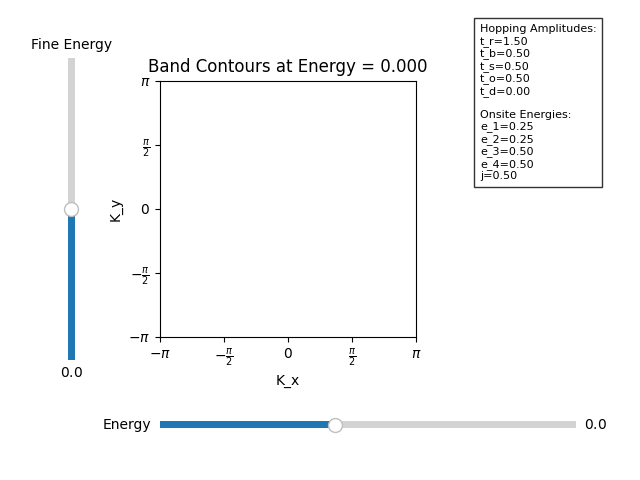

In [1]:
# Import modules
import numpy as np
from typing import Optional
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from matplotlib.figure import Figure
from matplotlib.axes import Axes
import pythtb

# Set PyPlot to interactive mode
%matplotlib widget

# noinspection PyUnresolvedReferences
class LiebLattice:
    """
    A tight-binding model for a 2D Lieb lattice.

    This class implements a tight-binding model for a Lieb lattice with 6 orbitals,
    supporting the calculation of eigenvalues for a k-point mesh and configuration
    of hopping amplitudes and onsite energies.

    Attributes
    ----------
    lattice_vectors : np.ndarray
        2D array of shape (2, 2) defining the lattice vectors [[1, 0], [0, 1]].
    orbital_vectors : np.ndarray
        2D array of shape (6, 2) defining the orbital positions.
    num_orbitals : int
        Number of orbitals (6).
    kpts : int
        Number of k-points per dimension for the k-space mesh.
    hops : np.ndarray
        1D NumPy array of shape (5,) containing hopping amplitudes [t_r, t_b, t_s, t_o, t_d].
    energies : np.ndarray
        1D NumPy array of shape (2,) containing onsite energies [e_nm, j], where `e_nm` is the onsite energy for the non-magnetic orbitals (0-3), and 
        `j` is the spin-dependent energy for the magnetic orbitals (4-5).
    kx : np.ndarray
        2D array of shape (kpts, kpts) containing x-components of k-points.
    ky : np.ndarray
        2D array of shape (kpts, kpts) containing y-components of k-points.
    kmesh : np.ndarray
        2D array of shape (kpts * kpts, 2) containing normalized k-points.
    model : pythtb.tb_model
        Tight-binding model instance from pythtb.
    bands_up : np.ndarray
        3D array of shape (kpts, kpts, num_orbitals) containing spin-up band energies.
    bands_down : np.ndarray
        3D array of shape (kpts, kpts, num_orbitals) containing spin-down band energies.
    """
    
    def __init__(self, kpts: int, hops: NDArray[np.float64], energies: NDArray[np.float64]):
        """
        Initialize a Lieb lattice tight-binding model.
    
        Initializes the model with a specified number of k-points, hopping amplitudes,
        and onsite energies, creating the k-space mesh via `_create_mesh` and computing
        initial spin-up and spin-down bands via `solve_model`.
    
        Parameters
        ----------
        kpts : int
            Number of k-points per dimension for the k-space mesh.
        hops : np.ndarray
            1D NumPy array of shape (5,) containing hopping amplitudes [t_r, t_b, t_s, t_o, t_d].
        energies : np.ndarray
            1D NumPy array of shape (2,) containing onsite energies [e_nm, j], where
            `e_nm` is the onsite energy for non-magnetic orbitals (0–3), and `j` is the
            spin-dependent energy for magnetic orbitals (4–5).
    
        Attributes
        ----------
        kpts : int
            Set from the input parameter.
        hops : np.ndarray
            Set from the input parameter.
        energies : np.ndarray
            Set from the input parameter.
        kx : np.ndarray
            2D array of shape (kpts, kpts) containing x-components of k-points, set by `_create_mesh`.
        ky : np.ndarray
            2D array of shape (kpts, kpts) containing y-components of k-points, set by `_create_mesh`.
        kmesh : np.ndarray
            2D array of shape (kpts * kpts, 2) containing normalized k-points, set by `_create_mesh`.
        model : pythtb.tb_model
            Tight-binding model instance from pythtb, initialized with lattice and orbital vectors.
        bands_up : np.ndarray
            3D array of shape (kpts, kpts, num_orbitals) containing spin-up band energies, set by `solve_model`.
        bands_down : np.ndarray
            3D array of shape (kpts, kpts, num_orbitals) containing spin-down band energies, set by `solve_model`.
    
        Raises
        ------
        ValueError
            If `hops` or `energies` have incorrect shapes, as checked by `_set_hops` or `_set_energies`.
    
        Notes
        -----
        The attributes `kx`, `ky`, and `kmesh` are initialized via `_create_mesh`.
        The attributes `bands_up` and `bands_down` are initialized via `solve_model`.
        """
        
        self.lattice_vectors = np.array([[1.0,0.0], [0.0,1.0]])
        self.orbital_vectors = np.array([[-0.25,0.25], [0.25,-0.25], [0.25,0.25], [0.75,0.75], [0.00,0.00], [0.50,0.50]])
        self.num_orbitals = self.orbital_vectors.shape[0]
        self.kpts: int = kpts
        self.hops: NDArray[np.float64] = hops
        self.energies: NDArray[np.float64] = energies
        self.kx: NDArray[np.float64] = np.linspace(start=-np.pi, stop=np.pi, num=self.kpts+1, endpoint=True)
        self.ky: NDArray[np.float64] = np.linspace(start=-np.pi, stop=np.pi, num=self.kpts+1, endpoint=True)
        self.kx, self.ky = np.meshgrid(self.kx, self.ky)
        self.kmesh: NDArray[np.float64] = np.hstack((self.kx.reshape((self.kx.size,1))/(2*np.pi),self.ky.reshape((self.ky.size,1))/(2*np.pi)))
        self.model_up: pythtb.tb_model = pythtb.tb_model(dim_k=2, dim_r=2, lat=self.lattice_vectors, orb=self.orbital_vectors, nspin=1)
        self.model_down: pythtb.tb_model = pythtb.tb_model(dim_k=2, dim_r=2, lat=self.lattice_vectors, orb=self.orbital_vectors, nspin=1)
        self.wf_up: pythtb.wf_array = pythtb.wf_array(model=self.model_up, mesh_arr=[self.kpts+1, self.kpts+1])
        self.wf_down: pythtb.wf_array = pythtb.wf_array(model=self.model_down, mesh_arr=[self.kpts+1, self.kpts+1])
        self.bands_up, self.bands_down = self.solve_model(hops, energies)
        
        
    def _set_hops(self, hops: NDArray[np.float64]) -> None:
        """
        Set hopping amplitudes for the tight-binding model.
        
        Configures hopping terms between orbitals in the Lieb lattice:
            `t_r` corresponds to favored hopping between non-magnetic and magnetic orbitals;
            `t_b` corresponds to unfavored hopping between magnetic and magnetic orbitals;
            `t_s` corresponds to hopping between same-spin magnetic orbitals;
            `t_o` corresponds to hopping between opposite-spin magnetic orbitals;
            `t_d` corresponds to hopping between non-magnetic orbitals.

        Parameters
        ----------
        hops : np.ndarray
            1D NumPy array of shape (5,) containing hopping amplitudes [t_r, t_b, t_s, t_o, t_d].
           
        Returns
        -------
        None
            Modifies the tight-binding model in-place by setting hopping amplitudes.
        
        Raises
        ------
        ValueError
            If `hops` is not a 1D array of shape (5,) containing hopping amplitudes [t_r, t_b, t_s, t_o, t_d].
        """
        if hops.shape != (5,):
            raise ValueError("hops must be a 1D array of shape (5,) containing hopping amplitudes [t_r, t_b, t_s, t_o, t_d].")
        for model in (self.model_up, self.model_down):
            for i in range(2):
                model.set_hop(hop_amp=hops[0], ind_i=4, ind_j=i, ind_R=[0,0], mode='reset')
                model.set_hop(hop_amp=hops[0], ind_i=5, ind_j=2+i, ind_R=[0,0], mode='reset')
                model.set_hop(hop_amp=hops[1], ind_i=4, ind_j=2+i, ind_R=[-i,-i], mode='reset') 
                model.set_hop(hop_amp=hops[1], ind_i=5, ind_j=i, ind_R=[1-i,i], mode='reset')
                model.set_hop(hop_amp=hops[2], ind_i=4, ind_j=4, ind_R=[1-i,i], mode='reset')
                model.set_hop(hop_amp=hops[3], ind_i=4, ind_j=5, ind_R=[-i,0], mode='reset')
                model.set_hop(hop_amp=hops[3], ind_i=4, ind_j=5, ind_R=[-i,-1], mode='reset')
                model.set_hop(hop_amp=hops[4], ind_i=2, ind_j=0, ind_R=[i,0], mode='reset')
                model.set_hop(hop_amp=hops[4], ind_i=2, ind_j=1, ind_R=[0,i], mode='reset')
                model.set_hop(hop_amp=hops[4], ind_i=3, ind_j=0, ind_R=[1,i], mode='reset')
                model.set_hop(hop_amp=hops[4], ind_i=3, ind_j=1, ind_R=[i,1], mode='reset')
            
    def _set_energies(self, energies: NDArray[np.float64]) -> None:
        """
        Set onsite energies for the tight-binding model.
        
        Sets the onsite energies for orbitals 0-3 (corresponding to the non-magnetic orbitals) to `energies[0]` and for orbitals 4-5
        to `±energies[1]` based on the spin configuration specified by `up`.
        
        Parameters
        ----------
        energies : np.ndarray
            1D NumPy array of shape (2,) containing onsite energies [e_nm, j], where `e_nm` is the onsite energy for the non-magnetic orbitals (0-3), and 
            `j` is the spin-dependent energy for the magnetic orbitals (4-5).
        up : bool, optional
            If True, sets spin-up energies: `j` for orbital 4 and `-j` for orbital 5.
            If False, sets spin-down energies: `-j` for orbital 4 and `j` for orbital 5.
            Default is True.
           
        Returns
        -------
        None
            Modifies the tight-binding model in-place by setting onsite energies 
        
        Raises
        ------
        ValueError
            If `energies` is not a 1D array of shape (2,) containing onsite energies [e_nm, j].
        """
        if energies.shape != (5,):
            raise ValueError("energies must be a 1D array of shape (5,) containing onsite energies [e_1, e_2, e_3, e_4, j].")
        for model in (self.model_up, self.model_down):
            for i in range(4):
                model.set_onsite(onsite_en=energies[i], ind_i=i, mode='reset')
        self.model_up.set_onsite(onsite_en=energies[4], ind_i=4, mode='reset')
        self.model_up.set_onsite(onsite_en=-energies[4], ind_i=5, mode='reset')
        self.model_down.set_onsite(onsite_en=-energies[4], ind_i=4, mode='reset')
        self.model_down.set_onsite(onsite_en=energies[1], ind_i=5, mode='reset')
    
    def solve_model(self, hops: Optional[NDArray[np.float64]] = None, energies: Optional[NDArray[np.float64]] = None) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
        """
        Solve the tight-binding model for given k-points.
    
        Updates the model with specified or stored hopping amplitudes and onsite energies,
        then computes eigenvalues for spin-up and spin-down configurations at the k-points in `kmesh`.
    
        Parameters
        ----------
        hops : np.ndarray, optional
            1D NumPy array of shape (5,) containing hopping amplitudes [t_r, t_b, t_s, t_o, t_d],
            passed to `_set_hops`. If None, uses stored `hops` attribute.
        energies : np.ndarray, optional
            1D NumPy array of shape (2,) containing onsite energies [e_nm, j], passed to
            `_set_energies`, where `e_nm` is the onsite energy for non-magnetic orbitals (0–3),
            and `j` is the spin-dependent energy for magnetic orbitals (4–5). If None, uses
            stored `energies` attribute.
    
        Returns
        -------
        tuple[np.ndarray, np.ndarray]
            Spin-up and spin-down eigenvalues, each reshaped to (kpts, kpts, num_orbitals).
    
        Raises
        ------
        ValueError
            If `hops` or `energies` have incorrect shapes, as checked by `_set_hops` or `_set_energies`.
    
        Notes
        -----
        The instance attributes `bands_up` and `bands_down` are only updated if new `hops` or
        `energies` are provided.
        """
        if hops is not None:
            self.hops = hops
        if energies is not None:
            self.energies = energies
        self._set_hops(self.hops)
        self._set_energies(self.energies)
        self.wf_up = pythtb.wf_array(model=self.model_up, mesh_arr=[self.kpts+1,self.kpts+1])
        self.wf_down = pythtb.wf_array(model=self.model_down, mesh_arr=[self.kpts+1,self.kpts+1])
        
        bands_up = np.zeros([self.kpts+1, self.kpts+1, self.num_orbitals])
        bands_down = np.zeros([self.kpts+1, self.kpts+1, self.num_orbitals])
        for i in range(self.kpts+1):
            for j in range(self.kpts+1):
                ikx = self.kx[0,i]/(2*np.pi)
                jky = self.ky[j,0]/(2*np.pi)
                (bands_up[i,j], self.wf_up[i,j]) = self.model_up.solve_one([ikx, jky], eig_vectors=True)
                (bands_down[i,j], self.wf_up[i,j]) = self.model_down.solve_one([ikx, jky], eig_vectors=True)
        return bands_up, bands_down
    
    def computer_berry_phase(self):
        for wf in (self.wf_up, self.wf_down):
            wf.impose_pbc(0,0)
            wf.impose_pbc(1,1)
            for band in (0,1,4,5):
                print(f"\nBerry Flux of Band {band}: ", np.round(wf.berry_flux([band], individual_phases=True),4))

# noinspection PyUnresolvedReferences
class BandContourPlot:
    """
    A class for visualizing band contours of a Lieb lattice tight-binding model.

    Creates an interactive Matplotlib plot with sliders to adjust the energy level for
    displaying band contours of spin-up and spin-down bands from a LiebLattice model.
    Includes a text annotation outside the plot displaying the hopping amplitudes and onsite energies.

    Attributes
    ----------
    lieb_lattice : LiebLattice
        The Lieb lattice tight-binding model instance.
    bands_up : np.ndarray
        3D array of shape (kpts, kpts, num_orbitals) containing spin-up band energies.
    bands_down : np.ndarray
        3D array of shape (kpts, kpts, num_orbitals) containing spin-down band energies.
    bands_up_min : np.ndarray
        1D array of shape (num_orbitals,) containing minimum energies for spin-up bands.
    bands_up_max : np.ndarray
        1D array of shape (num_orbitals,) containing maximum energies for spin-up bands.
    bands_down_min : np.ndarray
        1D array of shape (num_orbitals,) containing minimum energies for spin-down bands.
    bands_down_max : np.ndarray
        1D array of shape (num_orbitals,) containing maximum energies for spin-down bands.
    energy_min : float
        Minimum energy value for the rough adjustment slider, computed from band minima.
    energy_max : float
        Maximum energy value for the rough adjustment slider, computed from band maxima.
    fig : matplotlib.figure.Figure
        Matplotlib figure for the plot.
    ax : matplotlib.axes.Axes
        Matplotlib axes for the band contour plot.
    ax_energy : matplotlib.axes.Axes
        Matplotlib axes for the rough energy slider.
    ax_fine_energy : matplotlib.axes.Axes
        Matplotlib axes for the fine energy slider.
    energy_slider : matplotlib.widgets.Slider
        Slider for rough energy adjustment.
    fine_energy_slider : matplotlib.widgets.Slider
        Slider for fine energy adjustment.
    """

    def __init__(self, lieb_lattice: 'LiebLattice') -> None:
        """
        Initialize the band contour plot with sliders for energy adjustment.

        Sets up the Matplotlib figure, axes, and sliders, using band data from the provided
        Lieb lattice model. Computes band minima/maxima and energy ranges internally.

        Parameters
        ----------
        lieb_lattice : LiebLattice
            The Lieb lattice tight-binding model instance.

        Attributes
        ----------
        lieb_lattice : LiebLattice
            Set from the input parameter.
        bands_up : np.ndarray
            Set from `lieb_lattice.bands_up`.
        bands_down : np.ndarray
            Set from `lieb_lattice.bands_down`.
        bands_up_min : np.ndarray
            Computed internally.
        bands_up_max : np.ndarray
            Computed internally.
        bands_down_min : np.ndarray
            Computed internally.
        bands_down_max : np.ndarray
            Computed internally.
        energy_min : float
            Computed from band minima.
        energy_max : float
            Computed from band maxima.
        fig : matplotlib.figure.Figure
            Created internally.
        ax : matplotlib.axes.Axes
            Created internally.
        ax_energy : matplotlib.axes.Axes
            Created internally for the rough energy slider.
        ax_fine_energy : matplotlib.axes.Axes
            Created internally for the fine energy slider.
        energy_slider : matplotlib.widgets.Slider
            Created by `_create_sliders`.
        fine_energy_slider : matplotlib.widgets.Slider
            Created by `_create_sliders`.

        Raises
        ------
        ValueError
            If `lieb_lattice.bands_up` or `lieb_lattice.bands_down` do not have the shape (kpts, kpts, num_orbitals).
        """
        self.lieb_lattice = lieb_lattice
        self.bands_up = lieb_lattice.bands_up
        self.bands_down = lieb_lattice.bands_down
        self.bands_up_min: NDArray[np.float64] = np.min(a=self.bands_up, axis=(0, 1))
        self.bands_down_min: NDArray[np.float64] = np.min(a=self.bands_down, axis=(0, 1))
        self.bands_up_max: NDArray[np.float64] = np.max(a=self.bands_up, axis=(0, 1))
        self.bands_down_max: NDArray[np.float64] = np.max(a=self.bands_down, axis=(0, 1))
        self.energy_min: float = min(np.min(self.bands_up_min), np.min(self.bands_down_min))
        self.energy_max: float = max(np.max(self.bands_up_max), np.max(self.bands_down_max))

        # Validate array shapes
        expected_shape = (lieb_lattice.kpts+1, lieb_lattice.kpts+1, lieb_lattice.num_orbitals)
        if self.bands_up.shape != expected_shape or self.bands_down.shape != expected_shape:
            raise ValueError(f"bands_up and bands_down must have shape {expected_shape}")

        # Initialize the figure and sliders
        self.fig: Figure
        self.ax: Axes
        self.fig, self.ax = plt.subplots()
        plt.subplots_adjust(left=0.25, bottom=0.25, right=0.65)
        self._create_sliders()
        self._list_parameters()
        self._initialize_plot()

        # Connect sliders to update
        self.energy_slider.on_changed(self.update)
        self.fine_energy_slider.on_changed(self.update)

        # Initial plot
        self.update(None)
        plt.show()

    def _create_sliders(self) -> None:
        """
        Create sliders for rough and fine energy adjustments.

        Sets the instance attributes `ax_energy`, `ax_fine_energy`, `energy_slider`, and
        `fine_energy_slider` for interactive energy control.

        Attributes
        ----------
        ax_energy : matplotlib.axes.Axes
            Matplotlib axes for the rough energy slider.
        ax_fine_energy : matplotlib.axes.Axes
            Matplotlib axes for the fine energy slider.
        energy_slider : matplotlib.widgets.Slider
            Slider for rough energy adjustment.
        fine_energy_slider : matplotlib.widgets.Slider
            Slider for fine energy adjustment.

        Returns
        -------
        None
            Modifies the instance attributes in-place.
        """
        self.ax_energy: Axes = self.fig.add_axes((0.25, 0.1, 0.65, 0.03))
        self.energy_slider: Slider = Slider(
            ax=self.ax_energy,
            label='Energy',
            valmin=np.round(self.energy_min, decimals=1),
            valmax=np.round(self.energy_max, decimals=1),
            valinit=0.0,
            valstep=0.1
        )
        self.ax_fine_energy: Axes = self.fig.add_axes((0.1, 0.25, 0.0225, 0.63))
        self.fine_energy_slider: Slider = Slider(
            ax=self.ax_fine_energy,
            label='Fine Energy',
            valmin=-0.1,
            valmax=0.1,
            valinit=0.0,
            valstep=0.001,
            orientation='vertical'
        )
        
    def _list_parameters(self) -> None:
        """
        Create the textbox containing the hopping amplitudes and energies used in the model.
        
        Returns
        -------
        None
            Modifies the instance attributes in-place.
        """
        text_str = (
            f"Hopping Amplitudes:\n"
            f"t_r={self.lieb_lattice.hops[0]:.2f}\n"
            f"t_b={self.lieb_lattice.hops[1]:.2f}\n"
            f"t_s={self.lieb_lattice.hops[2]:.2f}\n"
            f"t_o={self.lieb_lattice.hops[3]:.2f}\n"
            f"t_d={self.lieb_lattice.hops[4]:.2f}\n\n"
            f"Onsite Energies:\n"
            f"e_1={self.lieb_lattice.energies[0]:.2f}\n"
            f"e_2={self.lieb_lattice.energies[1]:.2f}\n"
            f"e_3={self.lieb_lattice.energies[2]:.2f}\n"
            f"e_4={self.lieb_lattice.energies[3]:.2f}\n"
            f"j={self.lieb_lattice.energies[4]:.2f}"
        )
        self.fig.text(
            0.75, 0.95, text_str, 
            transform=self.fig.transFigure, 
            verticalalignment='top', 
            fontsize=8, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black')
        )

    def _initialize_plot(self) -> None:
        """
        Initialize the plot axes with labels, limits, tick marks, and model parameters.

        Configures the main axes for displaying band contours with appropriate labels
        and k-space limits. Adds a text annotation above the plot displaying the hopping
        amplitudes and onsite energies from the Lieb lattice model.

        Returns
        -------
        None
            Modifies the plot axes in-place.
        """
        self.ax.set_box_aspect(1)
        self.ax.set_xlabel('K_x')
        self.ax.set_ylabel('K_y')
        self.ax.set_xlim(-np.pi, np.pi)
        self.ax.set_ylim(-np.pi, np.pi)
        self.ax.set_xticks([(i - 2) * np.pi / 2 for i in range(5)])
        self.ax.set_xticklabels([r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"])
        self.ax.set_yticks([(i - 2) * np.pi / 2 for i in range(5)])
        self.ax.set_yticklabels([r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"])

    def update(self, _: Optional[float] = None) -> None:
        """
        Update the band contour plot based on the current slider values.

        Clears the current plot and redraws band contours for the energy level set by
        the rough and fine energy sliders, including a text annotation above the plot for model parameters.

        Parameters
        ----------
        _ : float, optional
            Slider value (ignored, as energy is taken from slider values directly).

        Returns
        -------
        None
            Updates the plot in-place.
        """
        energy: float = self.energy_slider.val + self.fine_energy_slider.val
        self.ax.clear()
        self._initialize_plot()
        self.ax.set_title(f'Band Contours at Energy = {energy:.3f}')

        # Plot bands at given energy
        for i in range(self.lieb_lattice.num_orbitals):
            if self.bands_up_min[i] < energy < self.bands_up_max[i]:
                self.ax.contourf(
                    self.lieb_lattice.kx, self.lieb_lattice.ky, self.bands_up[:, :, i],
                    levels=[self.bands_up_min[i], energy], colors='red', alpha=0.25
                )
                cs2 = self.ax.contour(
                    self.lieb_lattice.kx, self.lieb_lattice.ky, self.bands_up[:, :, i],
                    levels=[energy], colors='red'
                )
                if len(cs2.levels) <= 2:
                    self.ax.clabel(cs2, levels=cs2.levels, fmt=rf"{i+1}", colors='k', fontsize=10)

        for i in range(self.lieb_lattice.num_orbitals):
            if self.bands_down_min[i] < energy < self.bands_down_max[i]:
                self.ax.contourf(
                    self.lieb_lattice.kx, self.lieb_lattice.ky, self.bands_down[:, :, i],
                    levels=[self.bands_down_min[i], energy], colors='blue', alpha=0.25
                )
                cs2 = self.ax.contour(
                    self.lieb_lattice.kx, self.lieb_lattice.ky, self.bands_down[:, :, i],
                    levels=[energy], colors='blue'
                )
                if len(cs2.levels) <= 2:
                    self.ax.clabel(cs2, levels=cs2.levels, fmt=rf"{i+1}", colors='k', fontsize=10)

        self.fig.canvas.draw_idle()

    def close(self) -> None:
        """
        Close the Matplotlib figure.

        Releases resources associated with the plot.

        Returns
        -------
        None
            Closes the figure in-place.
        """
        plt.close(self.fig)

# Initialize the tight-binding model
myLiebLattice = LiebLattice(kpts=100, hops=np.array([1.5, 0.5, 0.5, 0.5, 0.0]), energies=np.array([0.25, 0.25, 0.5, 0.5, 0.5]))

# Solve tight-binding Hamiltonian
bandsUp, bandsDown = myLiebLattice.bands_up, myLiebLattice.bands_down
myLiebLattice.computer_berry_phase()
BandContourPlot(myLiebLattice);